In [ ]:
# Gerekli kütüphaneleri yükleme
!pip install -q diffusers transformers accelerate scipy safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.8 MB/s eta 0:00:00


In [2]:
from huggingface_hub import notebook_login

notebook_login()  # Bu komut, Hugging Face erişim token'i girmek için bir form açar.


In [5]:
#Gerekli kütüphaneler
from diffusers import StableDiffusionPipeline
import torch
from PIL import Image
from IPython.display import display

In [6]:
#Modeli indiriyoruz (float16 ile GPU uyumlu)
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [7]:
# NSFW filtresini devre dışı bırakıyoruz (isteğe bağlı)
pipe.safety_checker = None

In [8]:
#Modeli GPU'ya taşı
pipe = pipe.to("cuda")

In [9]:
#Görselleri oluşturma
prompt = "a sweet cat"  # prompt'u biraz düzelttim 😊
num_images = 3  # Oluşturulacak görsel sayısı
images = pipe(prompt, num_images_per_prompt=num_images).images

  0%|          | 0/50 [00:00<?, ?it/s]

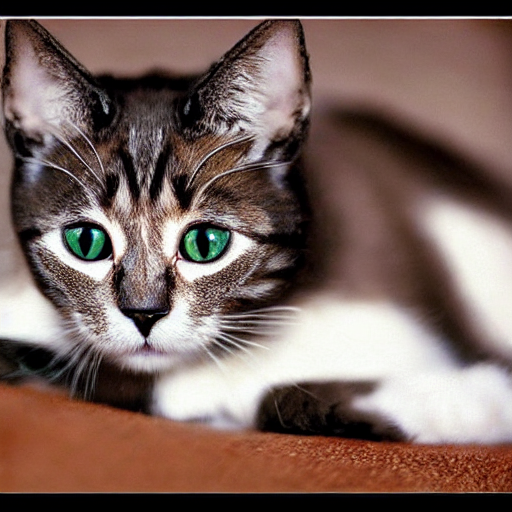

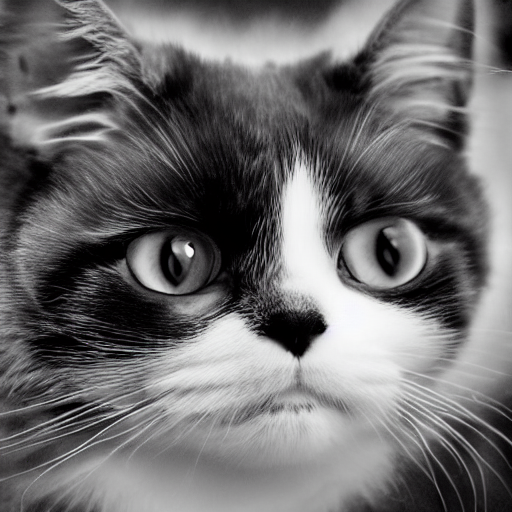

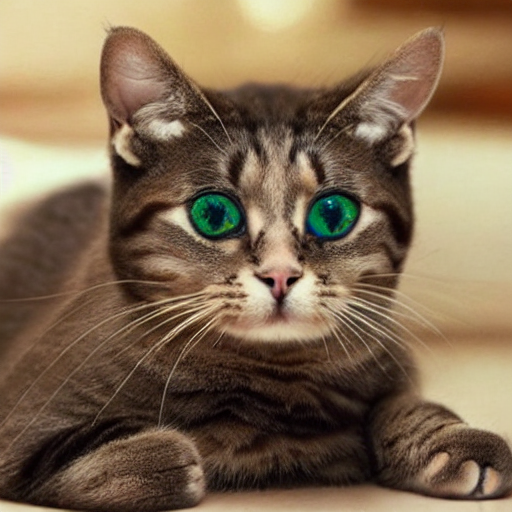

In [10]:
#Görselleri gösterme ve kaydetme
for idx, img in enumerate(images):
    display(img)
    img.save(f"generated_image_{idx + 1}.png")